# Raw Data Analysis

In [2]:
import json
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.dpi": 200,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

In [3]:
BOULDERS_PATH = "data/boulders.jsonl"
ASCENTS_PATH = "data/ascents.jsonl"

In [4]:
def grade_to_numeric(grade: str) -> float | None:
    mapping = {
        "2": 2, "3A": 3, "3B": 4, "3C": 5,
        "4A": 6, "4B": 7, "4C": 8,
        "5A": 9, "5B": 10, "5C": 11,
        "6A": 12, "6A+": 13, "6B": 14, "6B+": 15, "6C": 16, "6C+": 17,
        "7A": 18, "7A+": 19, "7B": 20, "7B+": 21, "7C": 22, "7C+": 23,
        "8A": 24, "8A+": 25, "8B": 26, "8B+": 27, "8C": 28, "8C+": 29,
    }
    return mapping.get(grade)

def grade_label(n: float) -> str:
    labels = ["2", "3A", "3B", "3C", "4A", "4B", "4C",
              "5A", "5B", "5C", "6A", "6A+", "6B", "6B+", "6C", "6C+",
              "7A", "7A+", "7B", "7B+", "7C", "7C+",
              "8A", "8A+", "8B", "8B+", "8C", "8C+"]
    idx = int(round(n)) - 2
    if 0 <= idx < len(labels):
        return labels[idx]
    return str(n)

In [5]:
boulders = []
with open(BOULDERS_PATH) as f:
    for line in f:
        b = json.loads(line)
        boulders.append(b)

ascents = []
with open(ASCENTS_PATH) as f:
    for line in f:
        a = json.loads(line)
        ascents.append(a)

print(f"Boulders: {len(boulders)}")
print(f"Ascents: {len(ascents)}")

Boulders: 11261
Ascents: 133155


## Ascents per Climber

In [6]:
climber_ascents = Counter()
for a in ascents:
    cid = a["climber_id"]
    name = a["climber_name"] or "Anonymous"
    key = cid if cid is not None else name
    if a["ascent_type"] != "toprope":
        climber_ascents[key] += 1

ascent_counts = list(climber_ascents.values())
print(f"Unique climbers: {len(climber_ascents)}")
print(f"Total ascents (exc. toprope): {sum(ascent_counts)}")
print(f"Mean ascents per climber: {np.mean(ascent_counts):.1f}")
print(f"Median ascents per climber: {np.median(ascent_counts):.1f}")
print(f"Max ascents: {max(ascent_counts)}")
print(f"Min ascents: {min(ascent_counts)}")

Unique climbers: 6374
Total ascents (exc. toprope): 133151
Mean ascents per climber: 20.9
Median ascents per climber: 8.0
Max ascents: 16895
Min ascents: 1


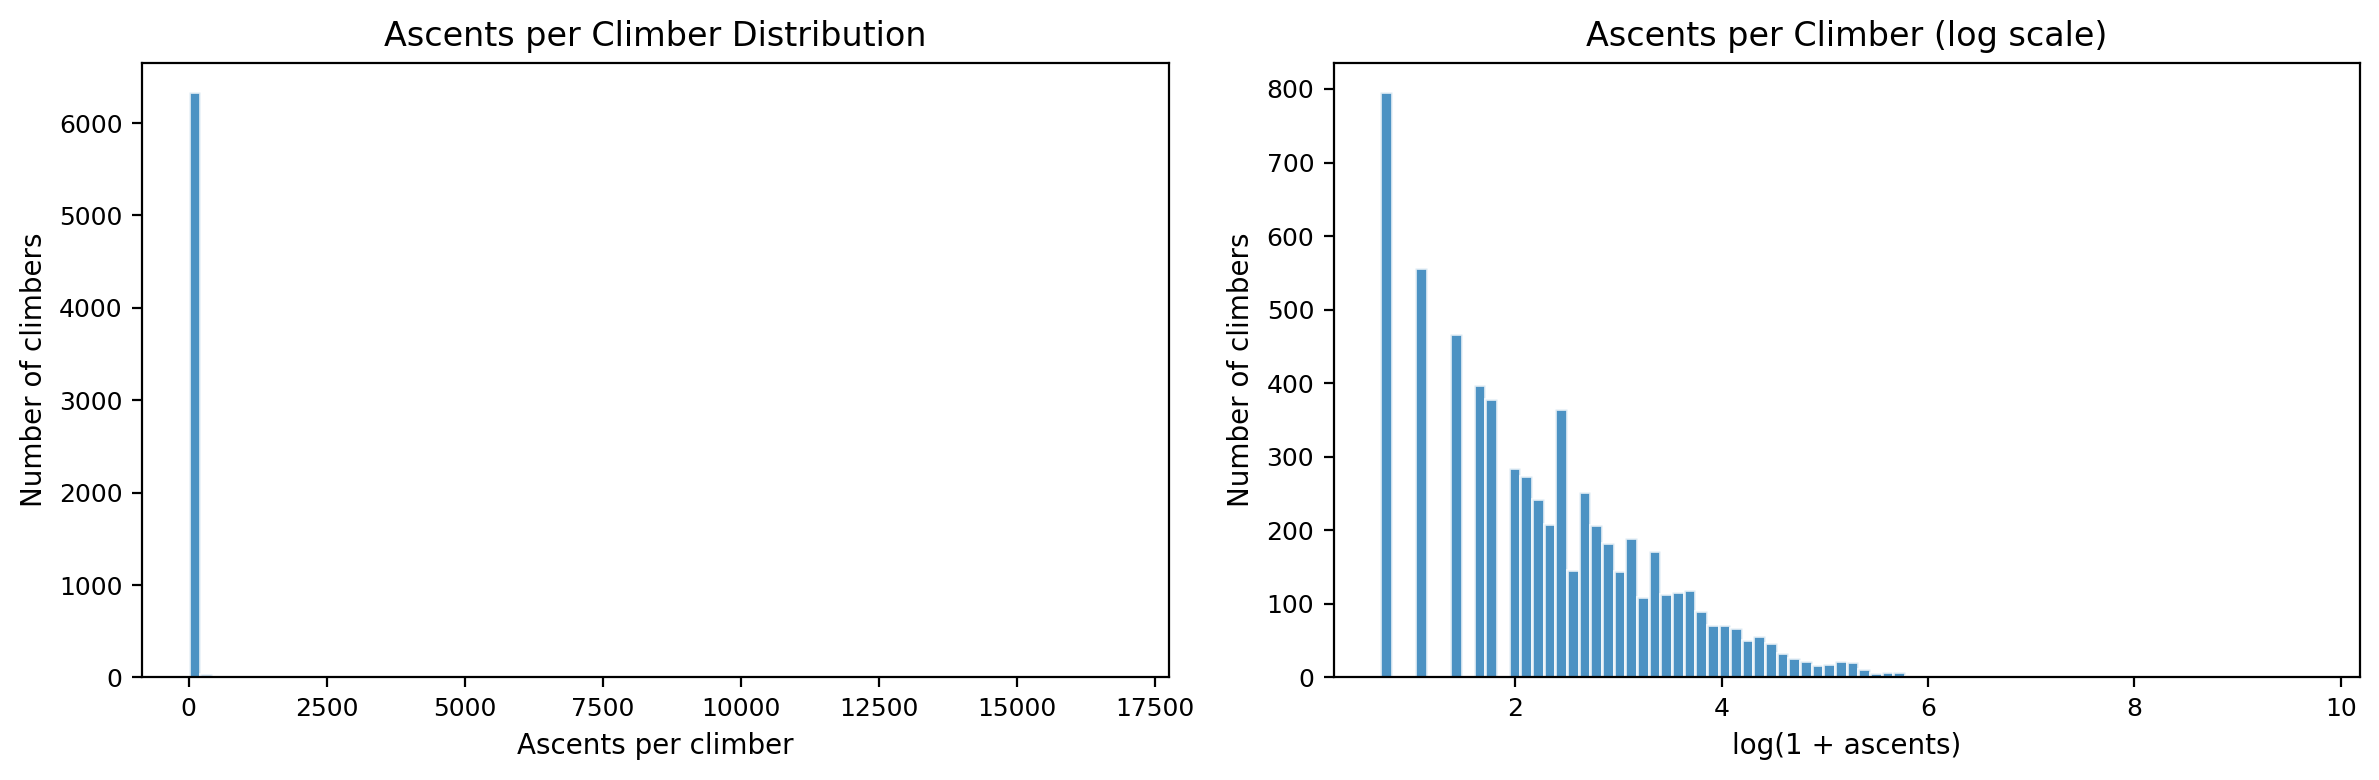

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ascent_counts, bins=80, color="#1f77b4", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Ascents per climber")
axes[0].set_ylabel("Number of climbers")
axes[0].set_title("Ascents per Climber Distribution")

axes[1].hist(np.log1p(ascent_counts), bins=80, color="#1f77b4", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("log(1 + ascents)")
axes[1].set_ylabel("Number of climbers")
axes[1].set_title("Ascents per Climber (log scale)")

fig.tight_layout()
plt.show()

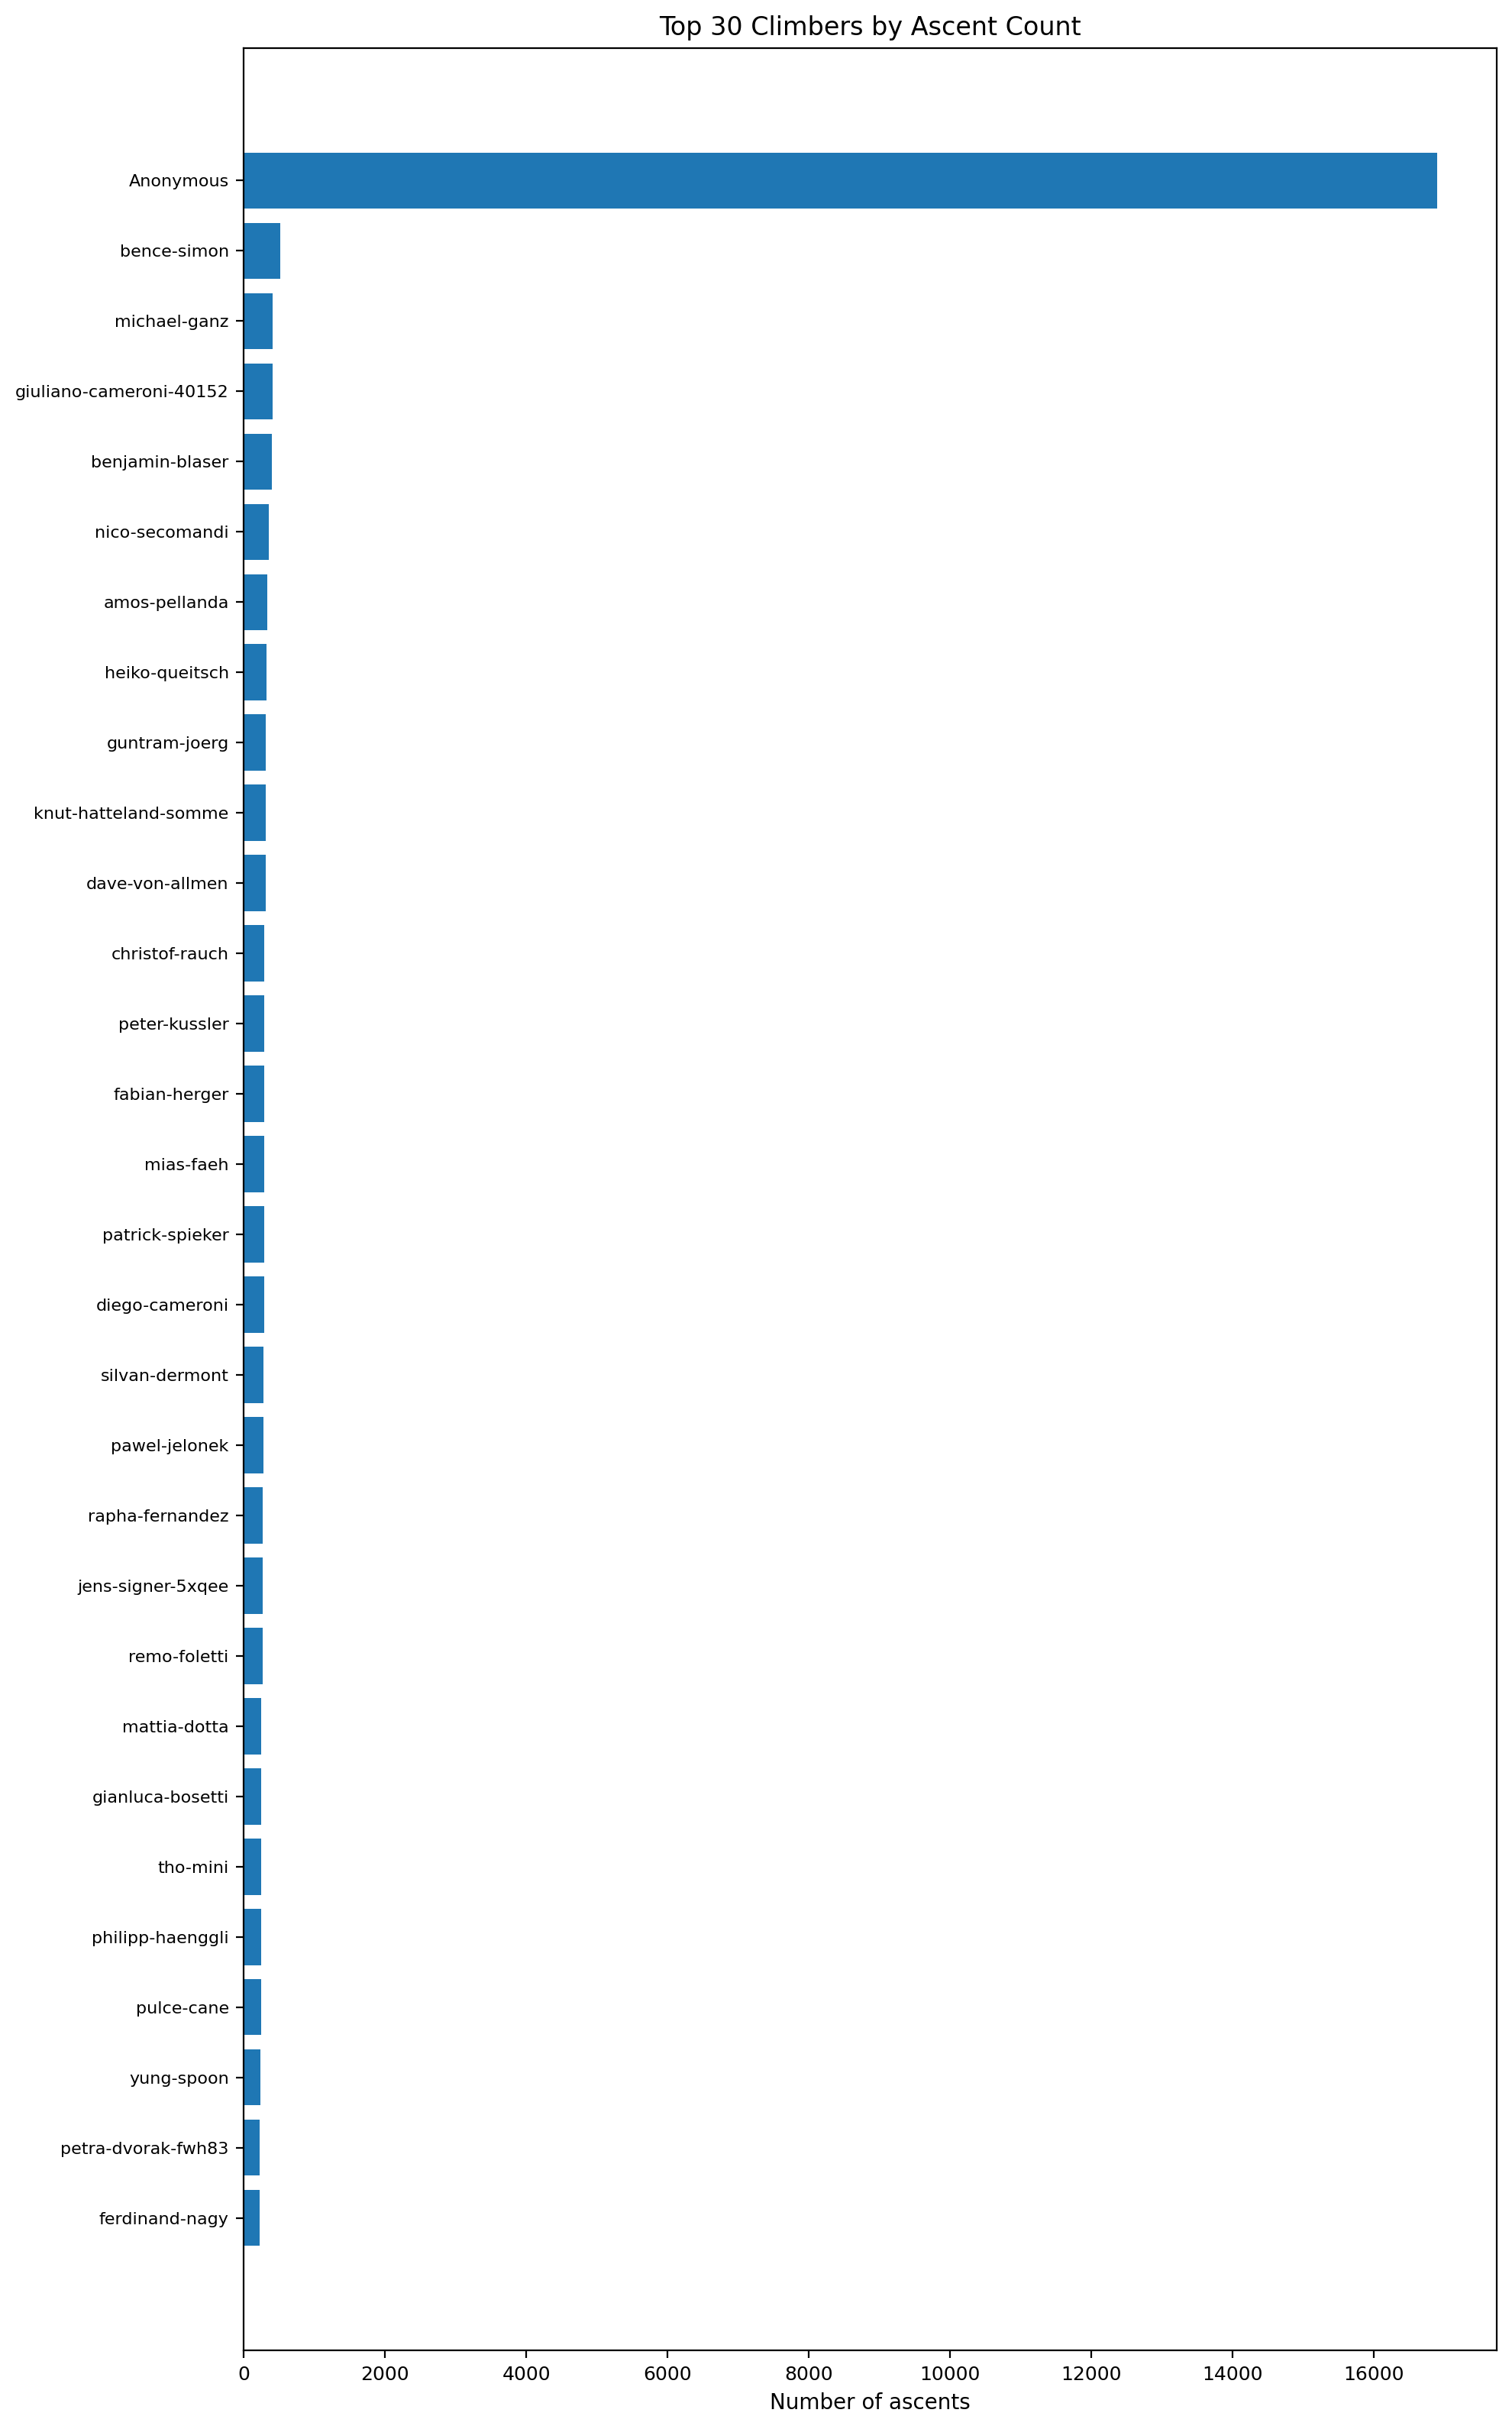

In [8]:
TOP_N = 30

top_climbers = climber_ascents.most_common(TOP_N)
names, counts = zip(*top_climbers)

fig, ax = plt.subplots(figsize=(10, 0.5 * TOP_N + 1))
ax.barh(range(len(names)), list(counts)[::-1], color="#1f77b4")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(list(names)[::-1], fontsize=8)
ax.set_xlabel("Number of ascents")
ax.set_title(f"Top {TOP_N} Climbers by Ascent Count")
fig.tight_layout()
plt.show()

## Boulder Distribution by Grade

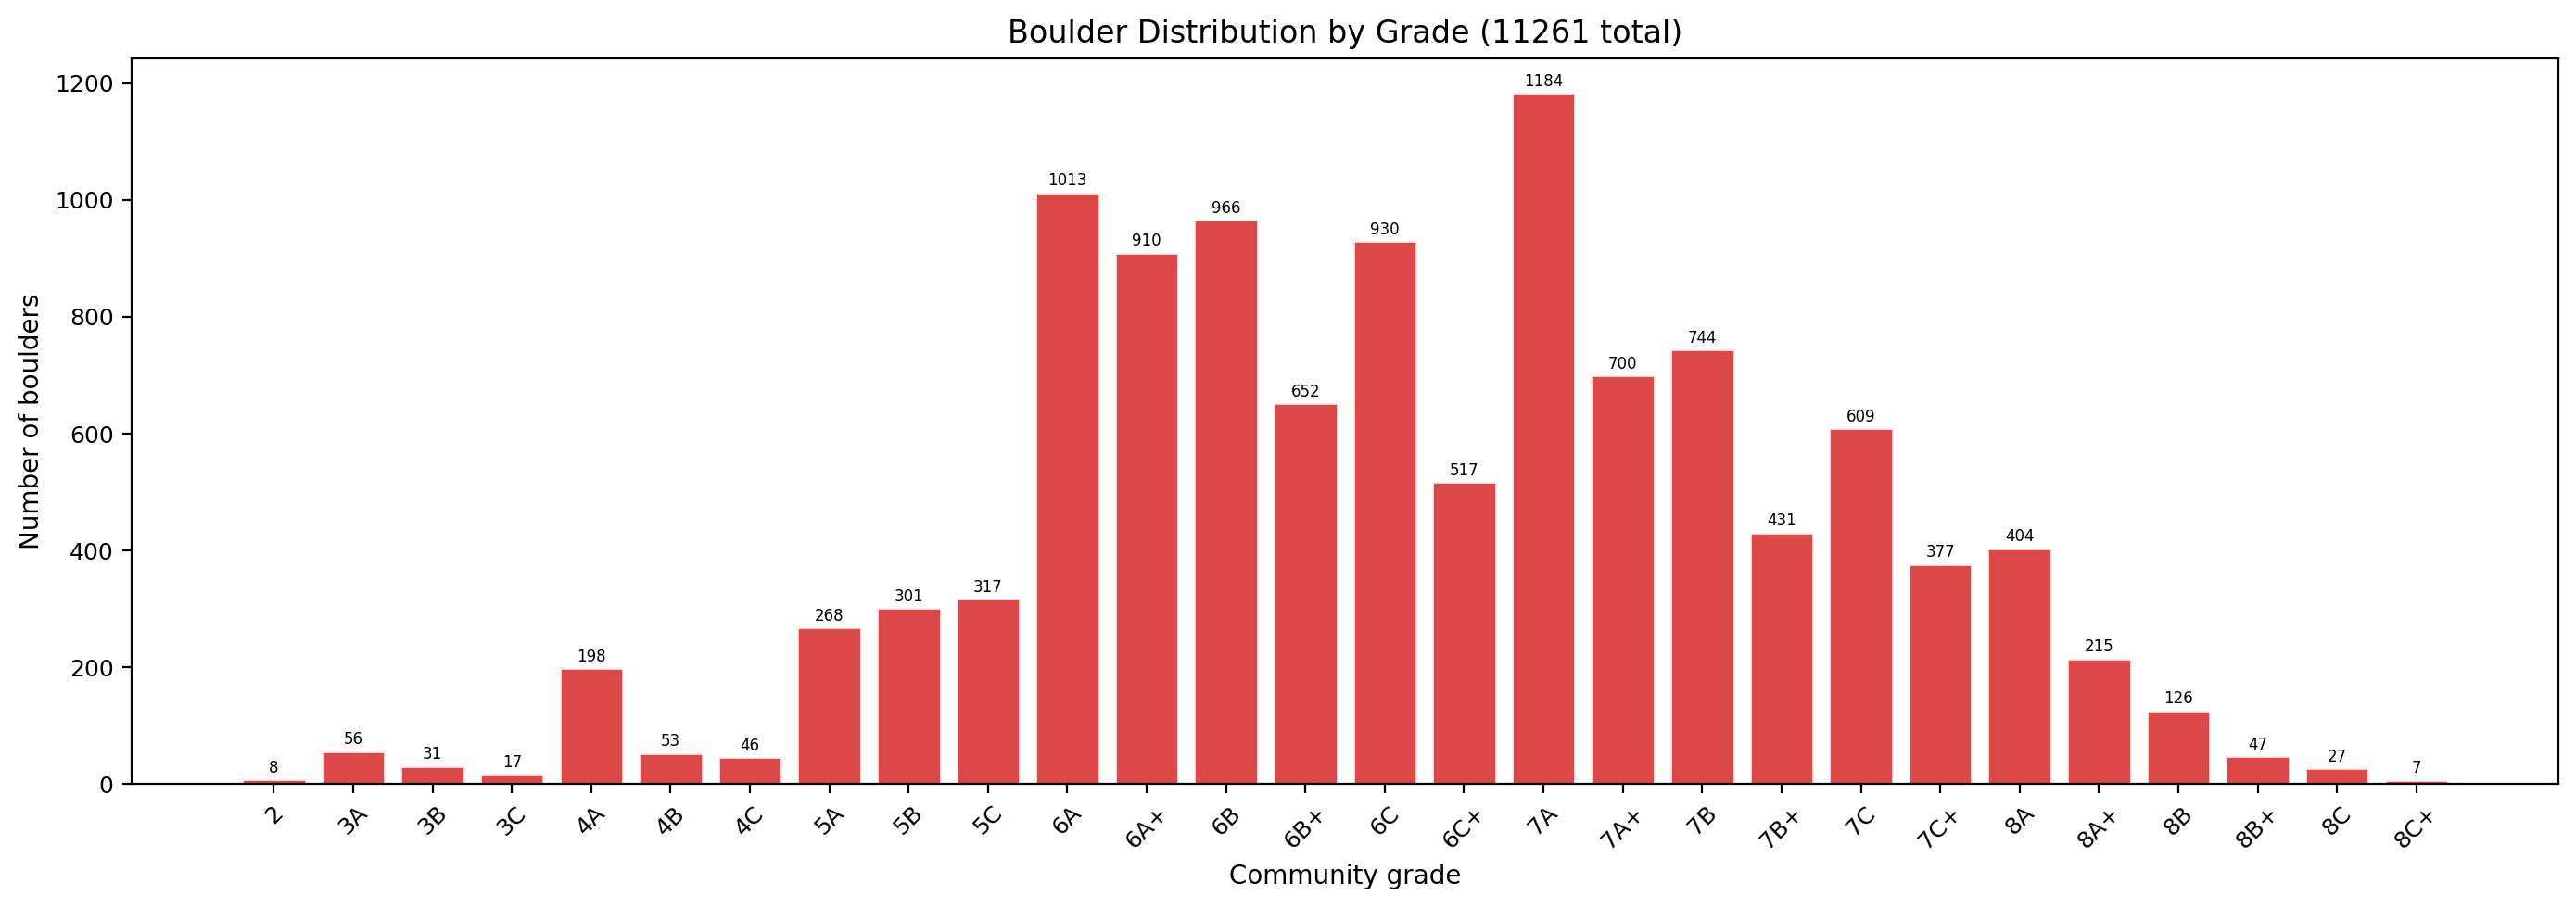

In [9]:
grade_counts = Counter()
for b in boulders:
    g = b.get("grade_community", "?")
    grade_counts[g] += 1

sorted_grades = sorted(
    (g for g in grade_counts if grade_to_numeric(g) is not None),
    key=lambda g: grade_to_numeric(g)
)
counts = [grade_counts[g] for g in sorted_grades]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(sorted_grades, counts, color="#d62728", edgecolor="white", alpha=0.85)
ax.set_xlabel("Community grade")
ax.set_ylabel("Number of boulders")
ax.set_title(f"Boulder Distribution by Grade ({len(boulders)} total)")
ax.tick_params(axis="x", rotation=45)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts) * 0.01,
            str(cnt), ha="center", fontsize=6)

fig.tight_layout()
plt.show()

## Anonymous Climbers

In [10]:
n_anon = 0
n_named = 0
for a in ascents:
    if a["climber_id"] is None:
        n_anon += 1
    else:
        n_named += 1

total = n_anon + n_named
print(f"Anonymous ascents: {n_anon} / {total} = {n_anon / total * 100:.1f}%")
print(f"Named ascents: {n_named} / {total} = {n_named / total * 100:.1f}%")

Anonymous ascents: 16895 / 133155 = 12.7%
Named ascents: 116260 / 133155 = 87.3%


In [11]:
anon_climber_ids = set()
named_climber_ids = set()
for a in ascents:
    if a["climber_id"] is None:
        anon_climber_ids.add(a["climber_name"])
    else:
        named_climber_ids.add(a["climber_id"])

print(f"Unique named climbers: {len(named_climber_ids)}")
print(f"Unique anonymous climbers (by name key): {len(anon_climber_ids)}")

Unique named climbers: 6374
Unique anonymous climbers (by name key): 1


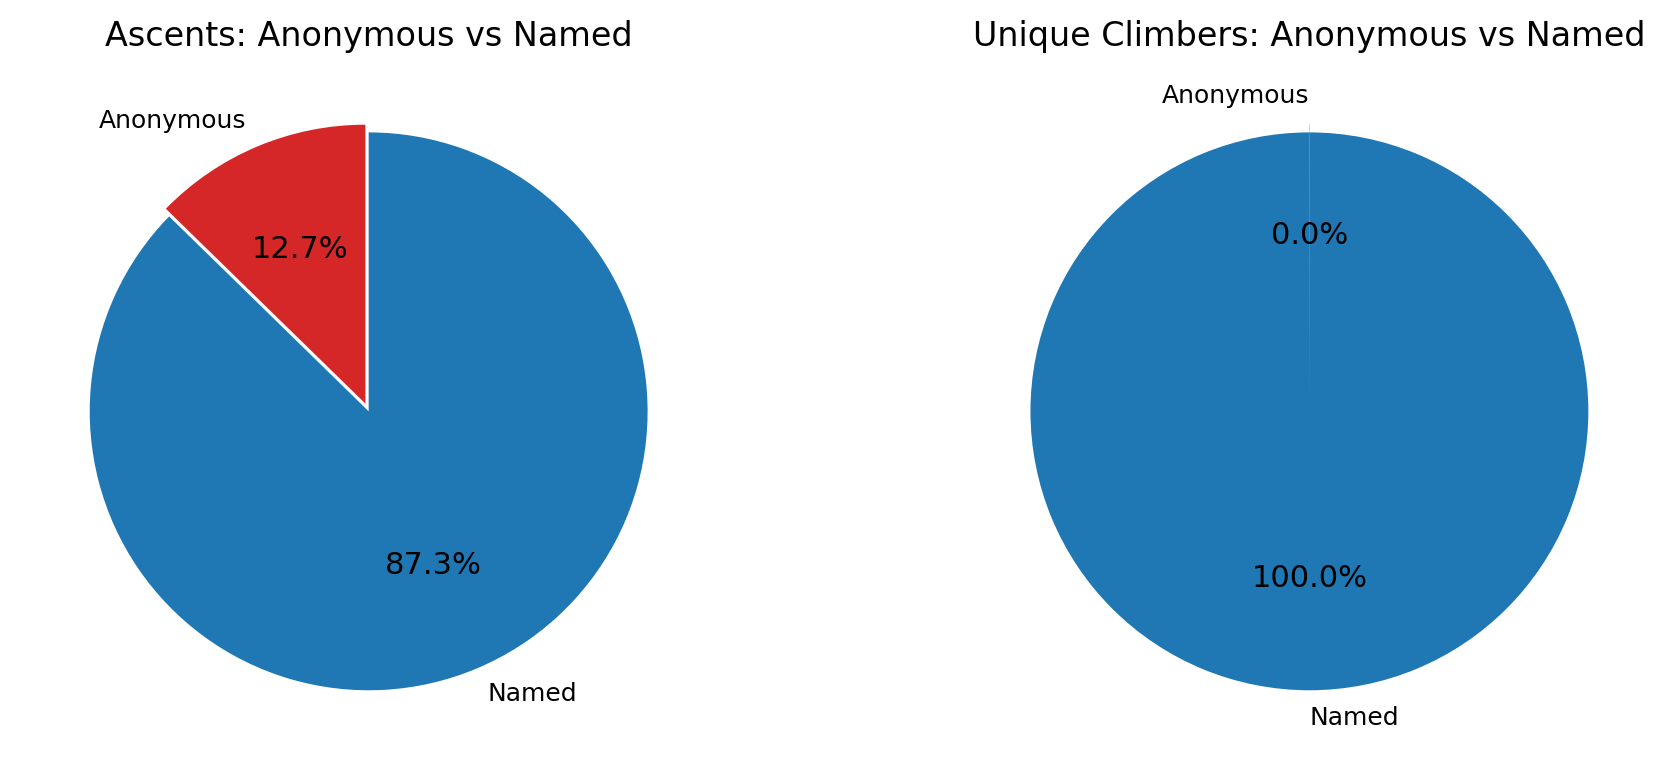

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ["#d62728", "#1f77b4"]
labels = ["Anonymous", "Named"]
sizes = [n_anon, n_named]

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, autopct="%1.1f%%", colors=colors,
    startangle=90, explode=(0.03, 0),
)
for t in autotexts:
    t.set_fontsize(11)
axes[0].set_title("Ascents: Anonymous vs Named")

anon_unique = len(anon_climber_ids)
named_unique = len(named_climber_ids)
wedges2, texts2, autotexts2 = axes[1].pie(
    [anon_unique, named_unique], labels=labels, autopct="%1.1f%%", colors=colors,
    startangle=90, explode=(0.03, 0),
)
for t in autotexts2:
    t.set_fontsize(11)
axes[1].set_title("Unique Climbers: Anonymous vs Named")

fig.tight_layout()
plt.show()

## Boulders with Fake/Placeholder Names

In [13]:
def is_fake_name(name: str) -> bool:
    clean = re.sub(r"[\s\-_().,]", "", name.strip().lower())
    return clean in ["nn", "nnn", "nnnn", "n.n", "n.n.", "no name", "noname", "??", "???", "project", "nameless"]

fake_boulders = []
real_boulders = []
for b in boulders:
    name = b["boulder_name"]
    if is_fake_name(name):
        fake_boulders.append(b)
    else:
        real_boulders.append(b)

print(f"Fake-name boulders: {len(fake_boulders)} / {len(boulders)} = {len(fake_boulders) / len(boulders) * 100:.1f}%")
print(f"Real-name boulders: {len(real_boulders)} / {len(boulders)} = {len(real_boulders) / len(boulders) * 100:.1f}%")

Fake-name boulders: 888 / 11261 = 7.9%
Real-name boulders: 10373 / 11261 = 92.1%


In [14]:
fake_boulders.sort(key=lambda x: x["ascent_count"])
fake_boulders[-1]

{'boulder_id': 46264,
 'boulder_name': 'N.N.',
 'crag_slug': 'magic-wood',
 'crag_name': 'Magic Wood',
 'category': 'bouldering',
 'country': 'switzerland',
 'sector': 'NN',
 'sector_slug': 'nn',
 'zlaggable_slug': 'unknown-boulder',
 'grade_community': '6C+',
 'average_rating': 3.31,
 'ascent_count': 620,
 'flash_count': 168,
 'redpoint_count': 403,
 'onsight_count': 48,
 'recommended_count': 3,
 'boulder_url': 'https://www.8a.nu/crags/bouldering/switzerland/magic-wood/sectors/nn/routes/unknown-boulder'}

In [15]:
fake_grade_counts = Counter()
for b in fake_boulders:
    fake_grade_counts[b.get("grade_community", "?")] += 1

sorted_fake = sorted(
    (g for g in fake_grade_counts if grade_to_numeric(g) is not None),
    key=lambda g: grade_to_numeric(g)
)

print("Fake-name boulders by grade:")
for g in sorted_fake:
    print(f"  {g}: {fake_grade_counts[g]}")
if "project" in fake_grade_counts:
    print(f"  project: {fake_grade_counts['project']}")

Fake-name boulders by grade:
  2: 2
  3A: 3
  3B: 6
  4A: 31
  4B: 6
  4C: 1
  5A: 73
  5B: 29
  5C: 30
  6A: 87
  6A+: 61
  6B: 66
  6B+: 58
  6C: 65
  6C+: 44
  7A: 80
  7A+: 59
  7B: 49
  7B+: 16
  7C: 22
  7C+: 11
  8A: 10
  8A+: 1
  8B: 1
  project: 77


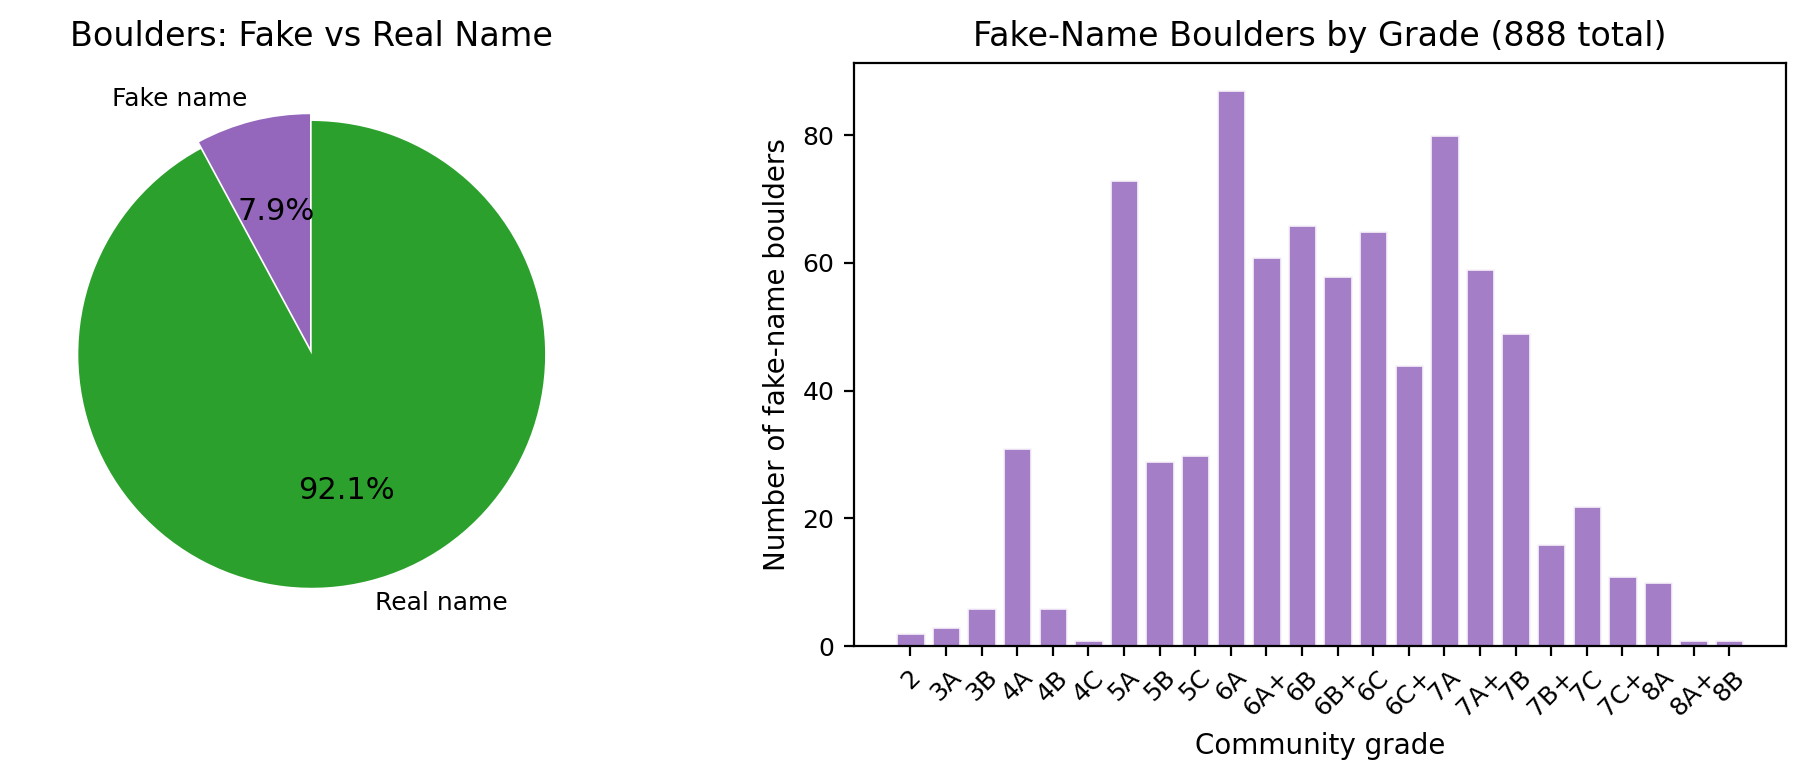

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors2 = ["#9467bd", "#2ca02c"]
labels2 = ["Fake name", "Real name"]
sizes2 = [len(fake_boulders), len(real_boulders)]

wedges, texts, autotexts = axes[0].pie(
    sizes2, labels=labels2, autopct="%1.1f%%", colors=colors2,
    startangle=90, explode=(0.03, 0),
)
for t in autotexts:
    t.set_fontsize(11)
axes[0].set_title("Boulders: Fake vs Real Name")

fake_counts = [fake_grade_counts.get(g, 0) for g in sorted_fake]
axes[1].bar(sorted_fake, fake_counts, color="#9467bd", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Community grade")
axes[1].set_ylabel("Number of fake-name boulders")
axes[1].set_title(f"Fake-Name Boulders by Grade ({len(fake_boulders)} total)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## Ascent Types Distribution

Ascent types:
  send: 102432
  flash: 25459
  onsight: 4160
  go: 1100
  toprope: 4


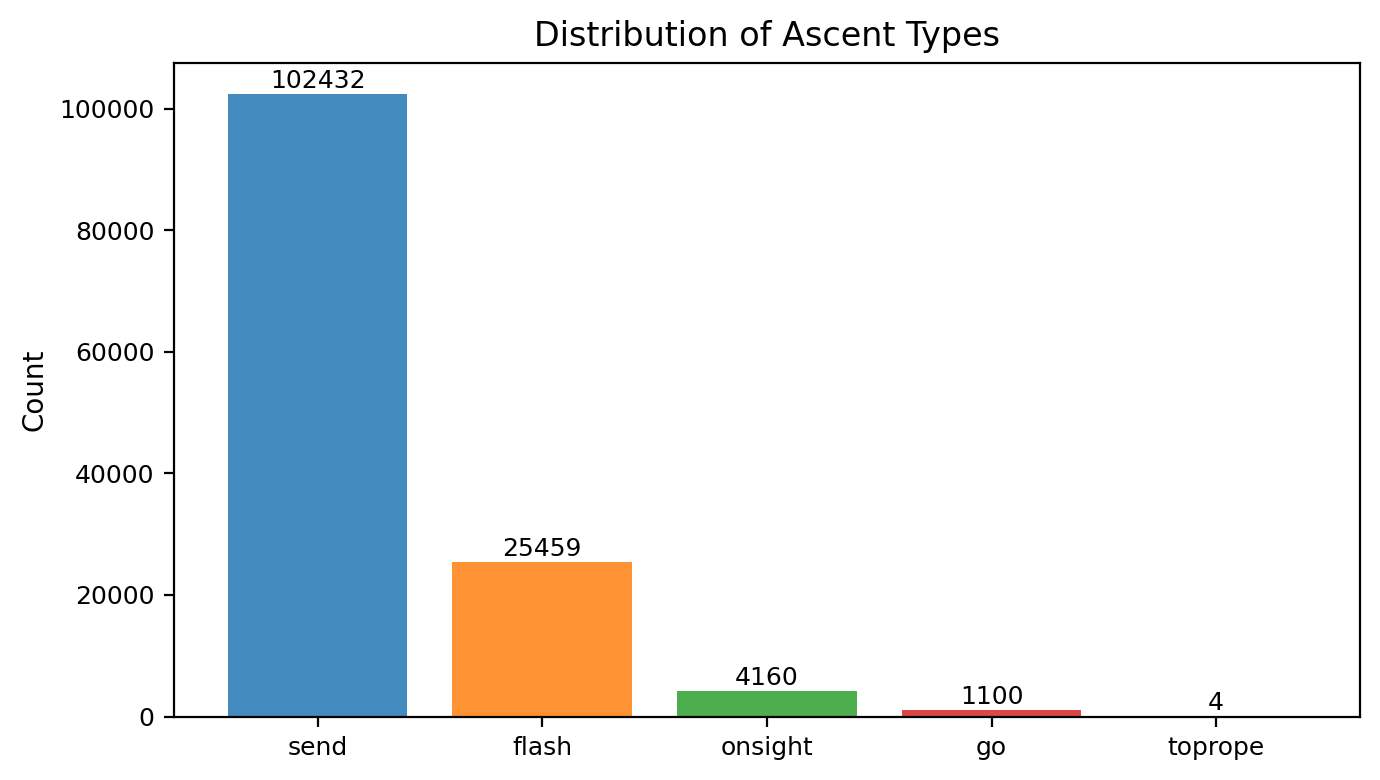

In [17]:
ascent_type_counts = Counter()
for a in ascents:
    ascent_type_counts[a["ascent_type"]] += 1

print("Ascent types:")
for atype, cnt in ascent_type_counts.most_common():
    print(f"  {atype}: {cnt}")

fig, ax = plt.subplots(figsize=(7, 4))
types, typecounts = zip(*ascent_type_counts.most_common())
bars = ax.bar(types, typecounts, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"], alpha=0.85)
ax.set_ylabel("Count")
ax.set_title("Distribution of Ascent Types")
for bar, cnt in zip(bars, typecounts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(typecounts) * 0.01,
            str(cnt), ha="center", fontsize=9)
fig.tight_layout()
plt.show()

## Ascents per Boulder

In [18]:
boulder_ascent_counts = Counter()
for a in ascents:
    if a["ascent_type"] != "toprope":
        boulder_ascent_counts[a["boulder_id"]] += 1

bcounts = list(boulder_ascent_counts.values())
print(f"Boulders with at least one ascent: {len(bcounts)}")
print(f"Mean ascents per boulder: {np.mean(bcounts):.1f}")
print(f"Median ascents per boulder: {np.median(bcounts):.1f}")
print(f"Max ascents: {max(bcounts)}")
print(f"Min ascents: {min(bcounts)}")

Boulders with at least one ascent: 11165
Mean ascents per boulder: 11.9
Median ascents per boulder: 2.0
Max ascents: 725
Min ascents: 1


In [27]:
tot = 0
for i in range(max(boulder_ascent_counts.values())):
    val = len([k for k in boulder_ascent_counts if boulder_ascent_counts[k] == i])
    tot += val
    print(f"{i}. {val}")
print(tot)

0. 0
1. 5477
2. 1508
3. 593
4. 494
5. 320
6. 285
7. 184
8. 168
9. 109
10. 104
11. 96
12. 95
13. 91
14. 79
15. 62
16. 60
17. 62
18. 61
19. 49
20. 50
21. 44
22. 32
23. 41
24. 51
25. 26
26. 21
27. 36
28. 24
29. 28
30. 34
31. 19
32. 25
33. 13
34. 18
35. 19
36. 13
37. 20
38. 19
39. 11
40. 13
41. 17
42. 15
43. 13
44. 13
45. 18
46. 11
47. 19
48. 13
49. 14
50. 21
51. 16
52. 6
53. 8
54. 9
55. 4
56. 6
57. 14
58. 7
59. 12
60. 5
61. 4
62. 7
63. 6
64. 7
65. 5
66. 4
67. 12
68. 9
69. 2
70. 4
71. 3
72. 11
73. 6
74. 6
75. 7
76. 4
77. 3
78. 4
79. 5
80. 8
81. 4
82. 7
83. 5
84. 4
85. 6
86. 3
87. 1
88. 2
89. 3
90. 2
91. 6
92. 3
93. 4
94. 2
95. 4
96. 3
97. 5
98. 5
99. 2
100. 4
101. 7
102. 5
103. 2
104. 1
105. 2
106. 3
107. 2
108. 1
109. 3
110. 0
111. 4
112. 3
113. 3
114. 3
115. 3
116. 5
117. 2
118. 2
119. 1
120. 2
121. 1
122. 5
123. 1
124. 6
125. 2
126. 3
127. 1
128. 0
129. 1
130. 3
131. 1
132. 1
133. 1
134. 5
135. 6
136. 2
137. 2
138. 1
139. 0
140. 0
141. 5
142. 0
143. 3
144. 1
145. 0
146. 1
147. 1
148. 1


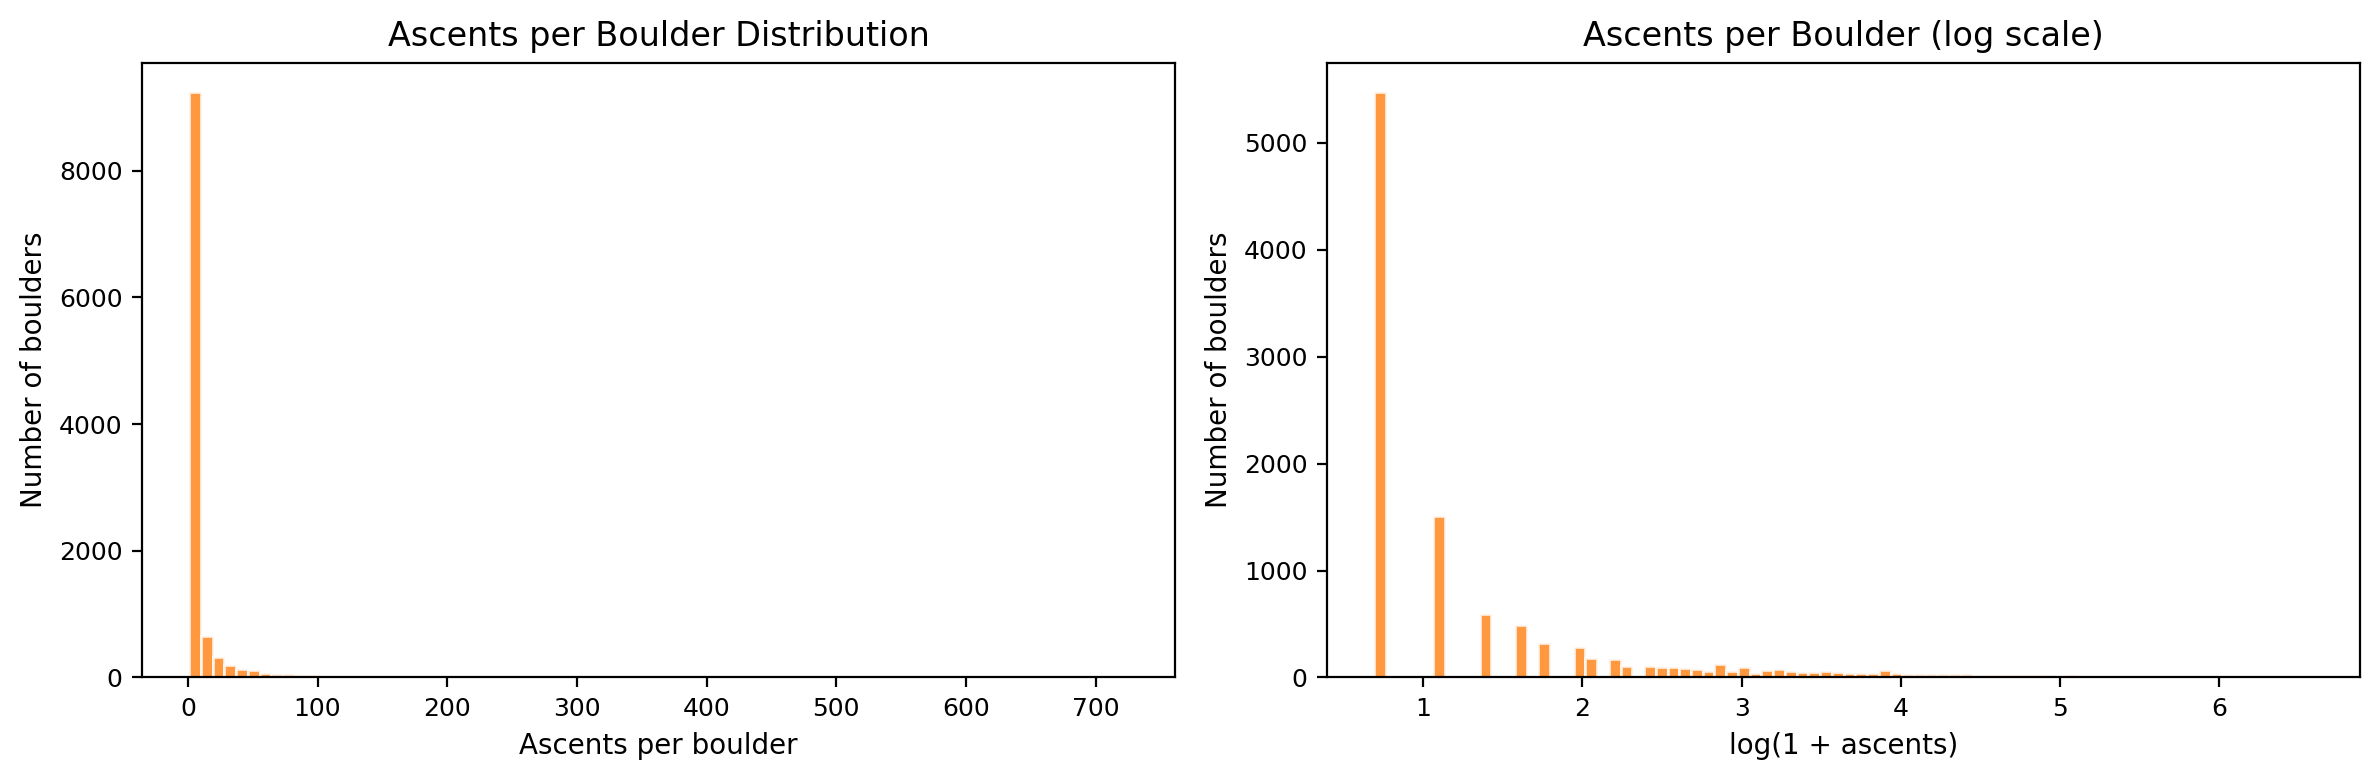

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(bcounts, bins=80, color="#ff7f0e", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Ascents per boulder")
axes[0].set_ylabel("Number of boulders")
axes[0].set_title("Ascents per Boulder Distribution")

axes[1].hist(np.log1p(bcounts), bins=80, color="#ff7f0e", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("log(1 + ascents)")
axes[1].set_ylabel("Number of boulders")
axes[1].set_title("Ascents per Boulder (log scale)")

fig.tight_layout()
plt.show()

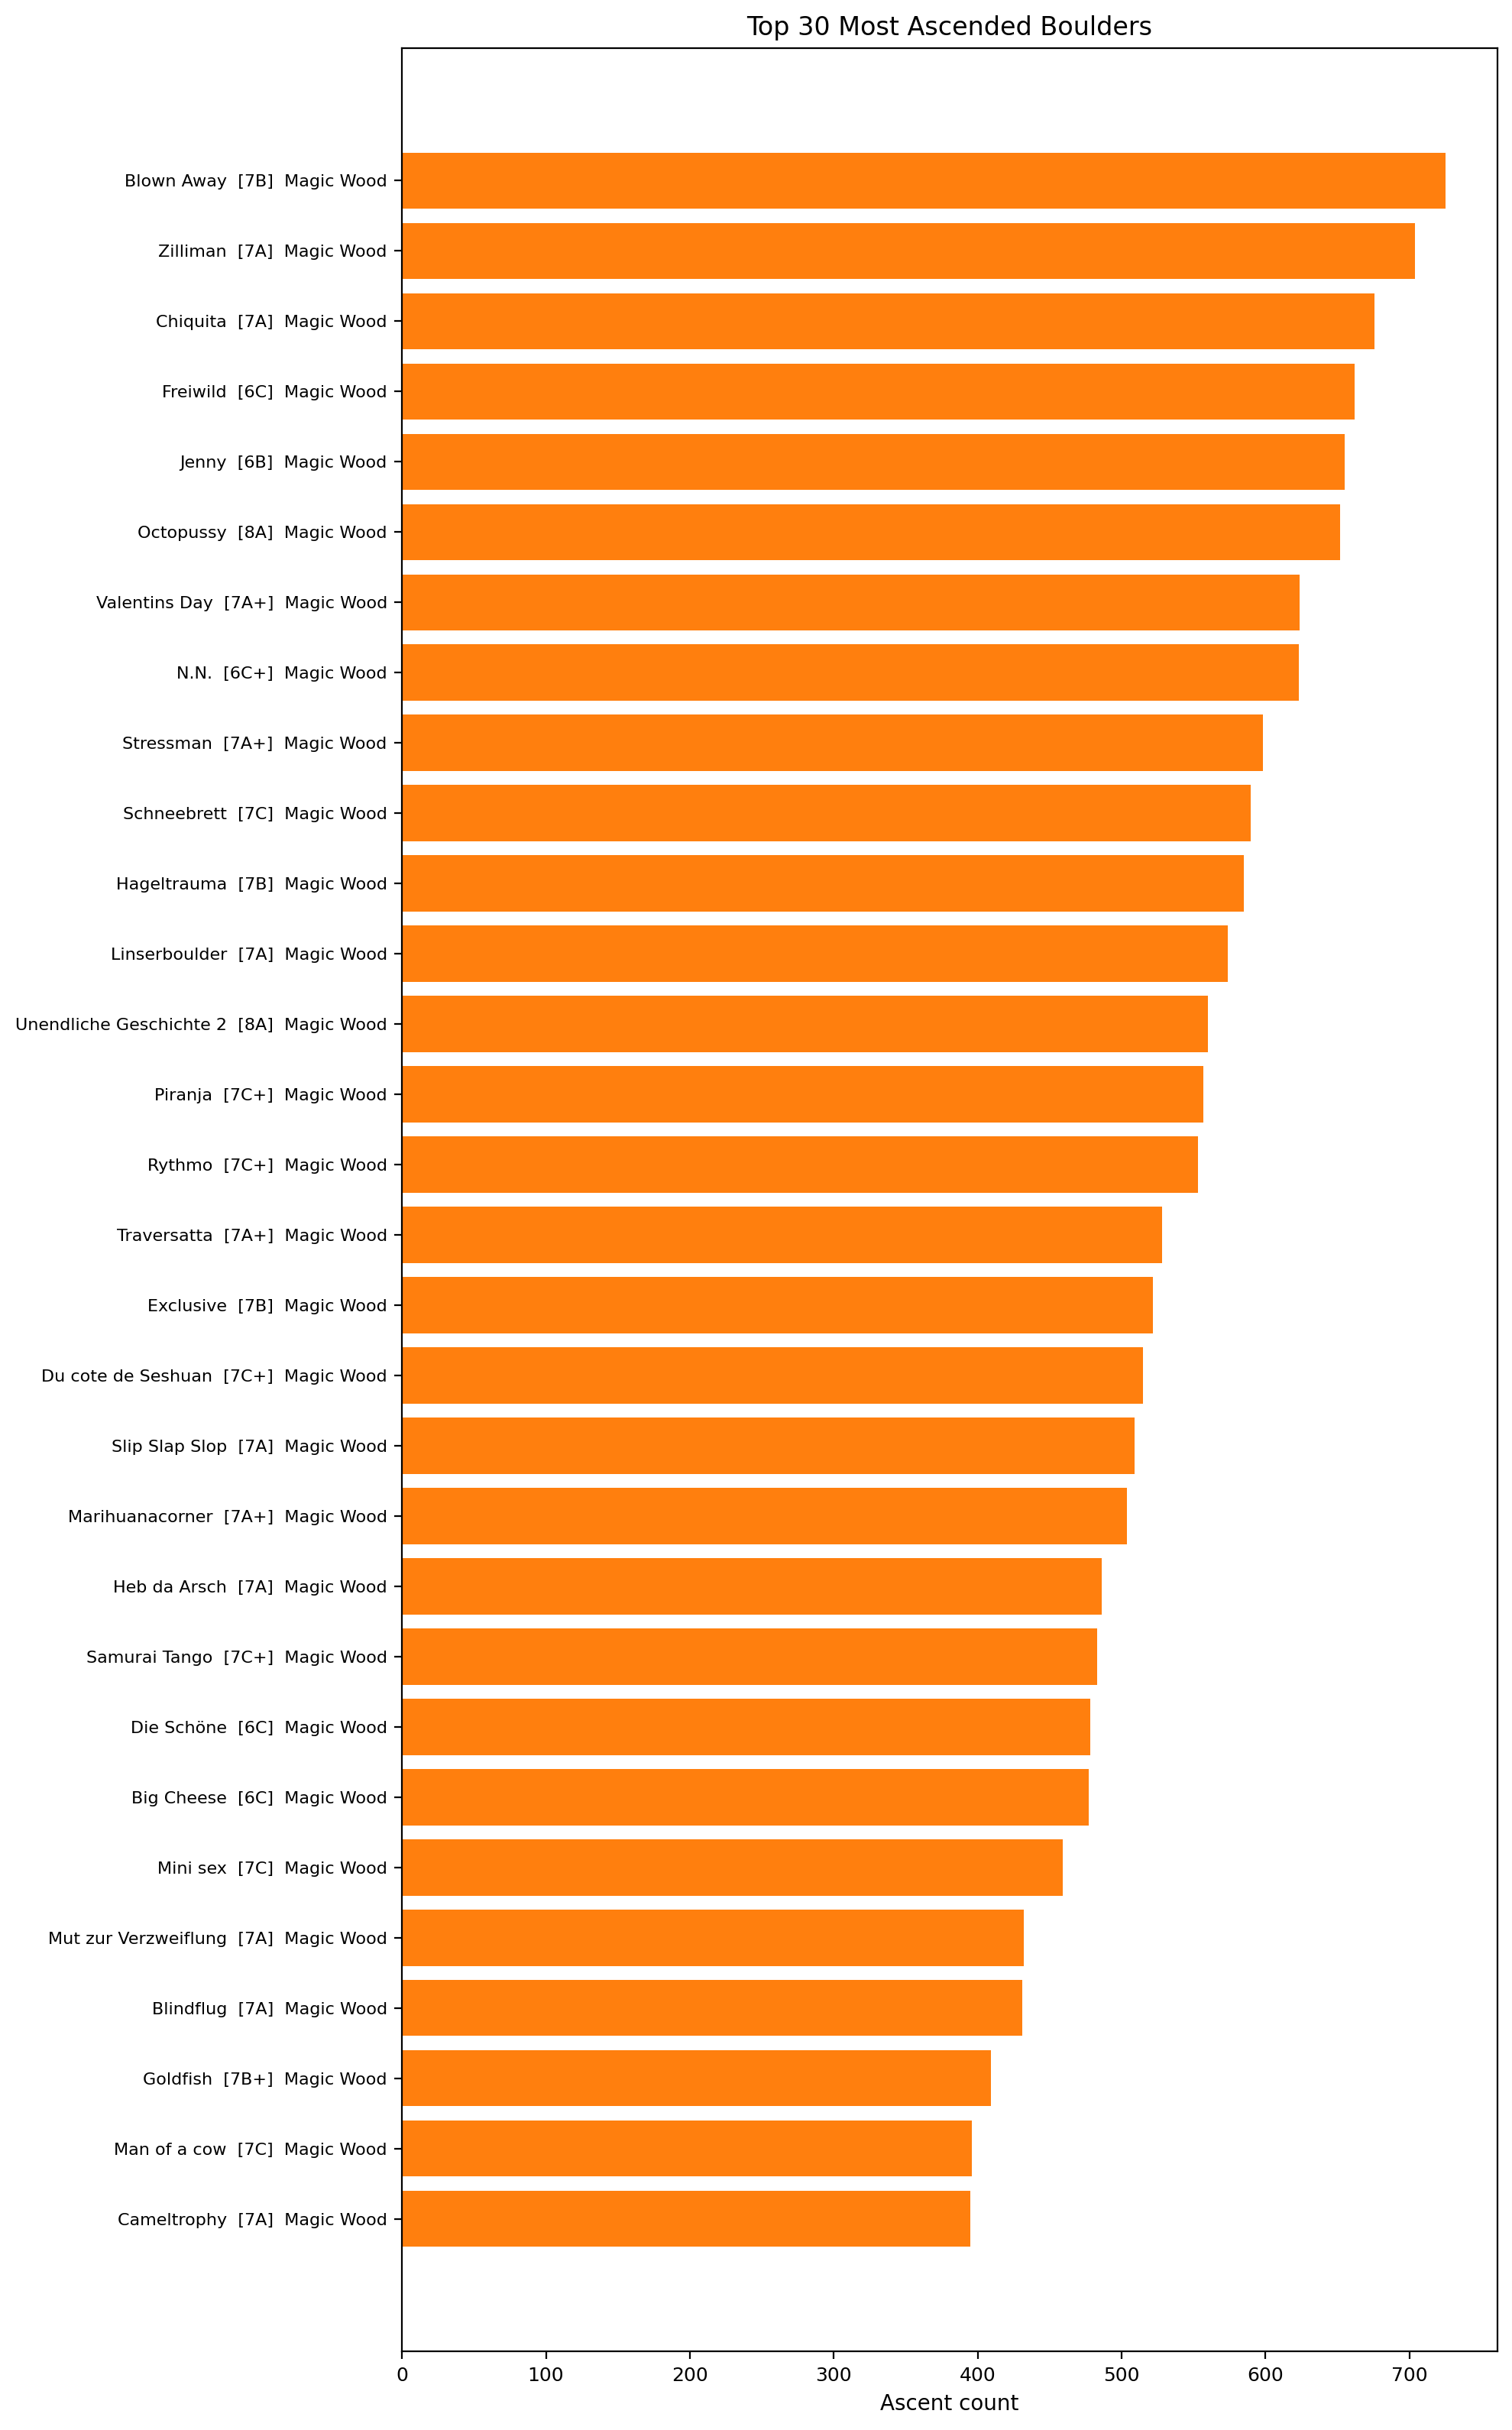

In [20]:
TOP_N = 30

top_boulders = boulder_ascent_counts.most_common(TOP_N)

boulder_name_map = {b["boulder_id"]: b["boulder_name"] for b in boulders}
boulder_crag_map = {b["boulder_id"]: b.get("crag_name", "?") for b in boulders}
boulder_grade_map = {b["boulder_id"]: b.get("grade_community", "?") for b in boulders}

labels = []
counts_list = []
for bid, cnt in reversed(top_boulders):
    name = boulder_name_map.get(bid, f"boulder_{bid}")
    crag = boulder_crag_map.get(bid, "?")
    grade = boulder_grade_map.get(bid, "?")
    labels.append(f"{name}  [{grade}]  {crag}")
    counts_list.append(cnt)

fig, ax = plt.subplots(figsize=(10, 0.5 * TOP_N + 1))
ax.barh(range(len(labels)), counts_list, color="#ff7f0e")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Ascent count")
ax.set_title(f"Top {TOP_N} Most Ascended Boulders")
fig.tight_layout()
plt.show()